<a href="https://colab.research.google.com/github/anirbansen2709/AI-ML_Assignments/blob/main/CV_assignment2_35_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2: Computer Vision (S2-25_AIMLCZG525)

**Video Presentation Link:** https://tinyurl.com/bdh67j6f

Dataset Link - https://drive.google.com/file/d/1ZccxVA6_VZEUmZeLTOPeH-skQpwi32ot

## Problem Statement 4: Fine-Tuning a Text-to-Image Model Using Crowd-Sourced Text-Image Pairs

You are given a small set of crowd-sourced images containing text, paired with corresponding text prompts. Your task is to fine-tune a pretrained text-to-image model so that it can generate images that visually resemble real operational text images when given a text prompt.

### Objective
Fine-tune a small text-to-image generation model to generate simple, readable text images using crowd-sourced text-image pairs collected from real-world operational contexts.

### Goal
* Understand Domain shift from synthetic to real data.
* Model adaptation using limited, noisy samples.
* Practical constraints of fine-tuning generative models on Colab.

---

### 1. Model Selection
**Stable Diffusion (v1.5 or v1.4) with LoRA fine-tuning**
* Fine-tune attention layers only
* Freeze base model
* Use `diffusers` + `peft`

### 2. Evaluation Criteria

**Qualitative Evaluation**
* Visual clarity of generated text
* Font and spacing realism
* Background consistency

**Quantitative Evaluation (Mandatory)**
* OCR-based readability test:
  `text` &rarr; `generated image` &rarr; `OCR` &rarr; `recovered text`

---
## 1. Environment Setup & Imports
Installing necessary libraries including `diffusers`, `peft` for LoRA, `bitsandbytes` for memory optimization, and `easyocr` for quantitative evaluation.

In [ ]:
# ==============================================================================
# Environment Setup & Library Installations
# ==============================================================================
# diffusers: Core library for working with Stable Diffusion pipelines.
# peft (Parameter-Efficient Fine-Tuning): Required for injecting LoRA adapters.
# bitsandbytes: Essential for loading the 8-bit optimizer to save VRAM on Colab T4.
# easyocr & Levenshtein: Required for Section 5 (Quantitative Evaluation metrics).
# ==============================================================================
!pip uninstall -y torchao
!pip install -q diffusers transformers peft accelerate datasets bitsandbytes easyocr Levenshtein
# Download the custom dataset directly from the provided GitHub repository
# !wget -q -O dataset.zip "https://github.com/anirbansen2709/sd15-lora-custom-dataset/raw/main/dataset.zip"
# Unzip the downloaded dataset into the target directory
!unzip -q dataset.zip -d ./dataset_folder/

replace ./dataset_folder/dataset/img_10.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [ ]:
# ==============================================================================
# IMPORT DEPENDENCIES
# ------------------------------------------------------------------------------
# Purpose: Import all required modules for deep learning (PyTorch),
# diffusion models (diffusers), memory optimization (peft, bitsandbytes),
# data handling (datasets, torchvision), and evaluation (easyocr).
# ==============================================================================

import os                                      # For interacting with the operating system (e.g., file paths, creating directories).
import torch                                   # The core PyTorch library for deep learning and handling tensors.
import torch.nn.functional as F                # Contains standard neural network functions (like MSE loss used later in training).
from diffusers import StableDiffusionPipeline, DDPMScheduler  # Loads the Stable Diffusion model and the scheduler for adding/removing noise.
from diffusers.optimization import get_scheduler              # Used to create learning rate schedulers (like the cosine warmup scheduler).
from peft import LoraConfig, get_peft_model    # Tools for Parameter-Efficient Fine-Tuning (PEFT); configures and injects LoRA into the model.
from datasets import load_dataset              # Hugging Face library used to easily download and load your custom image-text dataset.
from torchvision import transforms             # Provides common image transformations (resizing, converting to tensor, normalization).
from torch.utils.data import DataLoader        # Creates an iterable over the dataset to handle batching and shuffling during training.
import textwrap                                # Used to wrap and format long text strings nicely, mainly for visualizations.
from tqdm.auto import tqdm                     # Provides progress bars for loops, used to track training epochs and steps.
import bitsandbytes as bnb                     # Crucial for memory optimization; provides the 8-bit optimizer to save VRAM on the Colab T4 GPU.
import easyocr                                 # An Optical Character Recognition library used in Section 5 to read text from generated images.
import Levenshtein                             # Calculates string differences; used to compute the Character Accuracy metric against the OCR output.
import matplotlib.pyplot as plt                # Standard plotting library used to display images, charts, and training loss graphs.

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


## 2. Model Development & VRAM Optimization
We load `runwayml/stable-diffusion-v1-5` and apply mandatory VRAM optimizations to allow training on a Colab T4 GPU. The base model (VAE, UNet, Text Encoder) is frozen. We use Parameter-Efficient Fine-Tuning (PEFT) with LoRA targeting the UNet attention layers (`to_k`, `to_q`, `to_v`, `to_out.0`). An 8-bit AdamW optimizer and gradient checkpointing are utilized to manage memory constraints.

In [ ]:
print("Loading base model...")                           # Prints a status message to the console.
model_id = "runwayml/stable-diffusion-v1-5"              # Defines the Hugging Face repository ID for the base Stable Diffusion 1.5 model.
device = "cuda" if torch.cuda.is_available() else "cpu"  # Sets the device to GPU ("cuda") if available, otherwise falls back to CPU.

# Load Stable Diffusion v1.5 pipeline.
pipe = StableDiffusionPipeline.from_pretrained(          # Downloads and loads the pre-trained Stable Diffusion pipeline.
    model_id,
    torch_dtype=torch.float16,                           # Loads weights in 16-bit float (half precision) to save VRAM and speed up processing.
    safety_checker=None                                  # Disables the NSFW safety filter to save memory and avoid false positives during custom fine-tuning.
)

unet = pipe.unet                                         # Extracts the UNet model (the core component that actually denoises the image).
vae = pipe.vae                                           # Extracts the Variational Autoencoder (compresses images to latents and vice versa).
text_encoder = pipe.text_encoder                         # Extracts the CLIP text encoder (turns your text prompts into embeddings).
tokenizer = pipe.tokenizer                               # Extracts the tokenizer (turns text into tokens for the text encoder).

# Freeze base model parameters
vae.requires_grad_(False)                                # Freezes the VAE so its weights don't update during training (saves memory).
text_encoder.requires_grad_(False)                       # Freezes the text encoder (we are only fine-tuning the UNet).
unet.requires_grad_(False)                               # Freezes the entire base UNet before we add the trainable LoRA layers.

# VRAM Optimizations
unet.enable_gradient_checkpointing()                     # Trades compute for memory by recomputing intermediate activations during the backward pass (crucial for Colab T4).
vae.enable_slicing()                                     # Slices the VAE decoding process into steps to prevent VRAM spikes.

# Configure LoRA (Low-Rank Adaptation)
lora_config = LoraConfig(                                # Sets up the configuration for our Parameter-Efficient Fine-Tuning.
    r=32,                                                # Rank of the LoRA matrices; 32 is a good balance between expressiveness and memory.
    lora_alpha=64,                                       # Scaling factor for LoRA updates; keeping it equal to rank prevents aggressive scaling.
    target_modules=["to_k", "to_q", "to_v", "to_out.0"], # Specifies that we only want to inject LoRA into the UNet's attention layers (Keys, Queries, Values, Output).
    lora_dropout=0.1,                                    # Adds a 10% dropout rate to the LoRA layers to help prevent overfitting on small datasets.
    bias="none",                                         # Specifies that no biases should be trained, only the LoRA weights.
)

# Inject the LoRA adapters into the UNet
unet = get_peft_model(unet, lora_config)                 # Wraps our frozen UNet with the small, trainable LoRA layers defined above.
unet.to(device)                                          # Moves the UNet (now with LoRA) to the GPU.
vae.to(device)                                           # Moves the VAE to the GPU.
text_encoder.to(device)                                  # Moves the text encoder to the GPU.

Loading base model...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


CLIPTextModel(
  (embeddings): CLIPTextEmbeddings(
    (token_embedding): Embedding(49408, 768)
    (position_embedding): Embedding(77, 768)
  )
  (encoder): CLIPEncoder(
    (layers): ModuleList(
      (0-11): 12 x CLIPEncoderLayer(
        (self_attn): CLIPAttention(
          (k_proj): Linear(in_features=768, out_features=768, bias=True)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (out_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): CLIPMLP(
          (activation_fn): QuickGELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out_features=768, bias=True)
        )
        (layer_norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      )
    )
  )
  (final_layer_norm): LayerNo

## 3. Data Preprocessing
The dataset is loaded and transformed. Images are resized to 512x512, converted to tensors, and normalized. Text prompts are tokenized with padding and truncation. Raw PIL images are dropped to prevent DataLoader crashes during training.


### Dataset Overview
This dataset contains 100 real-world, smartphone-style images simulating operational text capture.
The data is explicitly split across 5 domains to prevent the model from overfitting to perfect document scans:

* **Domain 1:** Urban & Street (e.g., street signs, graffiti, awnings)
* **Domain 2:** Retail & Commerce (e.g., crumpled receipts, menus, barcodes)
* **Domain 3:** Office & Paperwork (e.g., sticky notes, messy envelopes)
* **Domain 4:** Logistics & Industrial (e.g., shipping labels, machinery plates)
* **Domain 5:** Digital & Screens (e.g., laptop glare, LED text, cracked screens)

**Formatting:** All images are center-cropped to 512x512. The `metadata.csv` uses a strict "Focal Text" prompting strategy (e.g., *'A smartphone photo of [object] with the text "[EXACT TEXT]"'*).

Link - https://github.com/anirbansen2709/sd15-lora-custom-dataset/blob/main/dataset.zip

In [ ]:
# ==============================================================================
# Data Preprocessing & Pipeline Construction
# ==============================================================================
print("Loading dataset...")
# Load the crowd-sourced operational text images
dataset = load_dataset("imagefolder", data_dir="./dataset_folder/", split="train")

# Define image transformations for the UNet
image_transforms = transforms.Compose([
    transforms.Resize((512, 512)),      # Standard resolution expected by SD v1.5
    transforms.ToTensor(),              # Convert PIL image to PyTorch tensor format (C, H, W)
    transforms.Normalize([0.5], [0.5]), # Normalize pixel values to the [-1, 1] range expected by the VAE
])

def preprocess_batch(examples):
    """
    Transforms raw dataset examples into model-ready tensors.
    """
    # Apply spatial transformations to RGB images
    pixel_values = [image_transforms(img.convert("RGB")) for img in examples["image"]]

    # Tokenize the text prompts to feed into the CLIP text encoder
    inputs = tokenizer(
        examples["text"],
        max_length=tokenizer.model_max_length,
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    )

    # Return ONLY PyTorch tensors.
    # Dropping the raw PIL images prevents the PyTorch DataLoader's default collate function from crashing.
    return {"pixel_values": pixel_values, "input_ids": inputs.input_ids}

# Apply the preprocessing mapping function to the dataset
processed_dataset = dataset.with_transform(preprocess_batch)

# Create the DataLoader with batch_size=1 due to strict Colab VRAM limits
train_dataloader = DataLoader(processed_dataset, batch_size=4, shuffle=True)
print(f"Dataset ready with {len(processed_dataset)} images!")

Loading dataset...


Resolving data files:   0%|          | 0/102 [00:00<?, ?it/s]

Dataset ready with 101 images!


In [ ]:
# ==============================================================================
# Optimization Setup
# ==============================================================================
epochs = 50
grad_accum_steps = 4

# Corrected learning rate for Stable Diffusion LoRA fine-tuning
optimizer = bnb.optim.AdamW8bit(unet.parameters(), lr=1e-5)

# Calculate total optimization steps dynamically from the dataloader length
num_batches_per_epoch = len(train_dataloader)
total_optimization_steps = (epochs * num_batches_per_epoch) // grad_accum_steps

# Warmup scaled to ~10% of total steps
num_warmup_steps = int(total_optimization_steps * 0.10)

lr_scheduler = get_scheduler(
    "cosine",
    optimizer=optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=total_optimization_steps
)

noise_scheduler = DDPMScheduler.from_pretrained(model_id, subfolder="scheduler")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Displaying 3 example images from the training dataset:


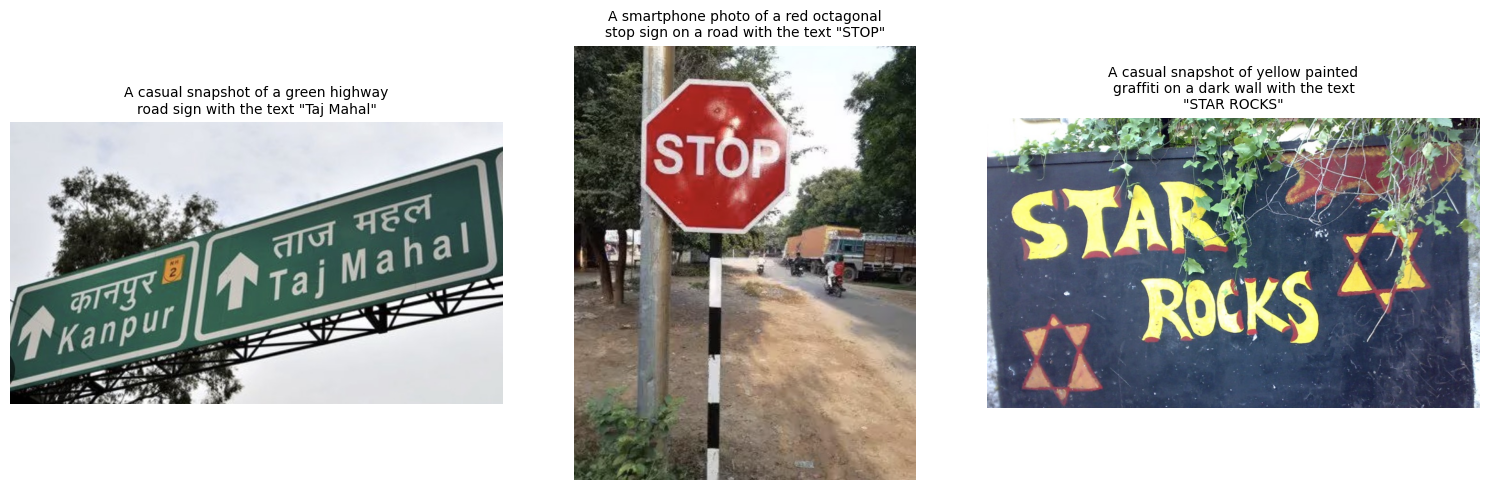

In [ ]:
# ==============================================================================
# Exploratory Data Analysis (EDA) - Visualizing Preprocessed Samples
# ==============================================================================
print("Displaying 3 example images from the training dataset:")

# Create a figure with 3 subplots arranged horizontally to verify image-text pairs
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i in range(3):
    # Access the raw dataset (which still contains the PIL images) for visualization
    example = dataset[i]
    img = example["image"]
    text_prompt = example["text"]

    # Display the image
    axes[i].imshow(img)
    axes[i].axis('off')

    # Wrap the text prompt so it fits nicely above the image without clipping
    wrapped_text = "\n".join(textwrap.wrap(text_prompt, width=40))
    axes[i].set_title(wrapped_text, fontsize=10)

plt.tight_layout()
plt.show()

## 4. Model Development / Training Loop
Training the LoRA adapters for 50 epochs. Gradient accumulation (steps = 4) is implemented to simulate a larger batch size, which is critical for stabilizing training on limited VRAM.

In [ ]:
# ==============================================================================
# Model Fine-Tuning (Training Loop)
# ==============================================================================
num_epochs = 50

# UPDATED: Increased accumulation steps from 8 to 16 for stabler batches
gradient_accumulation_steps = 4

output_dir = "./lora_weights_latest"

print(f"🚀 Starting Stabilized Training Loop for {num_epochs} epochs...")
unet.train()

# Store average loss per epoch for downstream visualization
epoch_losses = []
epoch_progress = tqdm(total=num_epochs, desc="Training Epochs")

for epoch in range(num_epochs):
    epoch_loss = 0.0

    for step, batch in enumerate(train_dataloader):
        # Move preprocessed inputs to the GPU
        clean_images = batch["pixel_values"].to(device, dtype=torch.float16)
        input_ids = batch["input_ids"].to(device)

        # Step 1: Encode images into latents
        latents = vae.encode(clean_images).latent_dist.sample() * vae.config.scaling_factor

        # Step 2: Add random noise
        noise = torch.randn_like(latents)
        timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (latents.shape[0],), device=device).long()
        noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

        # Step 3: Extract text embeddings
        encoder_hidden_states = text_encoder(input_ids)[0]

        # Step 4: Reverse Diffusion Process
        model_pred = unet(noisy_latents, timesteps, encoder_hidden_states).sample

        # Step 5: Calculate MSE loss
        loss = F.mse_loss(model_pred.float(), noise.float(), reduction="mean")
        loss = loss / gradient_accumulation_steps
        loss.backward()

        # Step 6: Gradient Accumulation & Weight Update Logic
        if (step + 1) % gradient_accumulation_steps == 0 or (step + 1) == len(train_dataloader):
            # UPDATED: Clip gradients to a max norm of 1.0 to prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(unet.parameters(), max_norm=1.0)

            optimizer.step()
            lr_scheduler.step() #  Step the learning rate scheduler
            optimizer.zero_grad()

        # Accumulate loss
        epoch_loss += loss.item() * gradient_accumulation_steps

    # Calculate average loss
    avg_epoch_loss = epoch_loss / len(train_dataloader)
    epoch_losses.append(avg_epoch_loss)

    # Continuous Checkpointing
    unet.save_pretrained(output_dir)

    epoch_progress.update(1)

epoch_progress.close()
print(f"✅ Training Complete! Latest model weights are safely stored in: {output_dir}")

🚀 Starting Stabilized Training Loop for 50 epochs...


Training Epochs:   0%|          | 0/50 [00:00<?, ?it/s]

✅ Training Complete! Latest model weights are safely stored in: ./lora_weights_latest


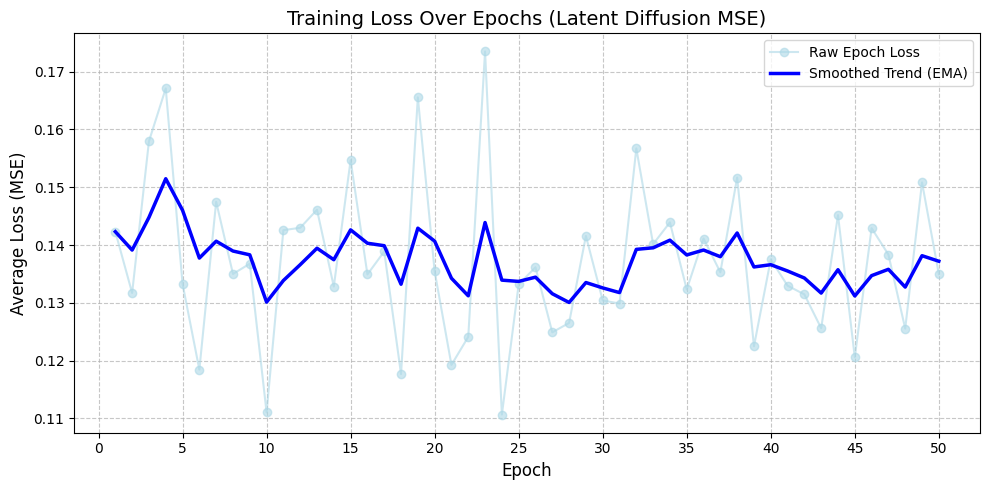

In [ ]:
# ==============================================================================
# Training Convergence Visualization
# ==============================================================================
# JUSTIFICATION FOR SMOOTHING:
# Unlike standard classification, diffusion models sample a random timestep (t)
# and random noise for every batch. The loss magnitude varies wildly depending
# on the timestep chosen. With a small dataset (100 images), this causes the
# epoch average to appear highly volatile. We apply Exponential Moving Average
# (EMA) smoothing to reveal the underlying convergence trend.
# ==============================================================================
import numpy as np

def smooth_curve(scalars, weight=0.7):
    """EMA smoothing function to reveal trends in noisy diffusion loss."""
    last = scalars[0]
    smoothed = []
    for point in scalars:
        smoothed_val = last * weight + (1 - weight) * point
        smoothed.append(smoothed_val)
        last = smoothed_val
    return smoothed

smoothed_losses = smooth_curve(epoch_losses, weight=0.7)

plt.figure(figsize=(10, 5))

# Plot raw noisy loss in the background (light color to show reality)
plt.plot(range(1, num_epochs + 1), epoch_losses, marker='o', linestyle='-',
         color='lightblue', alpha=0.6, label='Raw Epoch Loss')

# Plot smoothed trend line in the foreground (dark color to show the actual learning trend)
plt.plot(range(1, num_epochs + 1), smoothed_losses, marker='', linestyle='-',
         color='blue', linewidth=2.5, label='Smoothed Trend (EMA)')

# Formatting the plot for academic readability
plt.title('Training Loss Over Epochs (Latent Diffusion MSE)', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Average Loss (MSE)', fontsize=12)

# Dynamically adjust x-ticks so they don't overlap if you increase epochs later
plt.xticks(np.arange(0, num_epochs + 1, step=max(1, num_epochs//10)))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

## 5. Quantitative Evaluation
Testing the model using an OCR-based readability test pipeline: `text -> generated image -> OCR -> recovered text`. We evaluate using Exact String Match and Levenshtein Character Accuracy metrics on unseen prompts.


### Metric Definitions & Details

#### 1. Exact String Match
* **How it's calculated:** `target_text.lower() in ocr_text.lower()`
* **What it means:** This is a **strict pass/fail (True/False)** metric. It checks if the exact phrase we wanted the model to generate appears perfectly in the OCR output. If even one letter is missing or wrong in the sequence, it fails entirely.

#### 2. Levenshtein Character Accuracy
* **How it's calculated:** $ \left( 1 - \frac{\text{Levenshtein Distance}}{\text{Length of Target}} \right) \times 100\% $
* **What it means:** This is a **granular metric (0–100%)**. Instead of just pass/fail, it counts the minimum number of single-character edits (insertions, deletions, or substitutions) needed to fix the generated text. This gives the model "partial credit" if it successfully generates a few correct letters but messes up the rest of the word.


🔎 Starting Section 5: Evaluation Pipeline...

--- Generating Image for Test Case 1 ---


  0%|          | 0/30 [00:00<?, ?it/s]

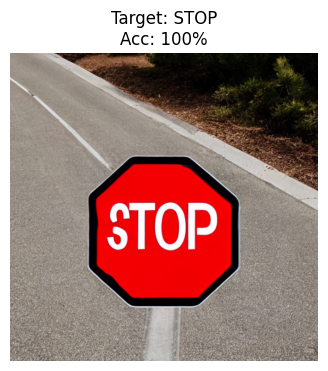


--- Generating Image for Test Case 2 ---


  0%|          | 0/30 [00:00<?, ?it/s]

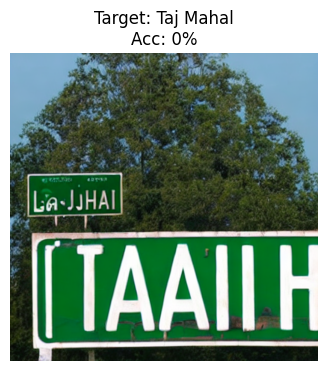


--- Generating Image for Test Case 3 ---


  0%|          | 0/30 [00:00<?, ?it/s]

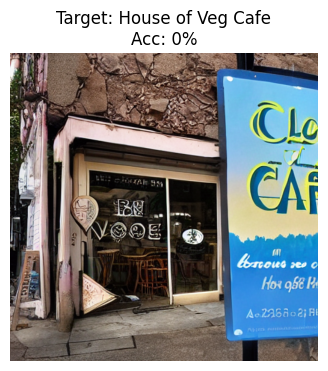


--- Generating Image for Test Case 4 ---


  0%|          | 0/30 [00:00<?, ?it/s]

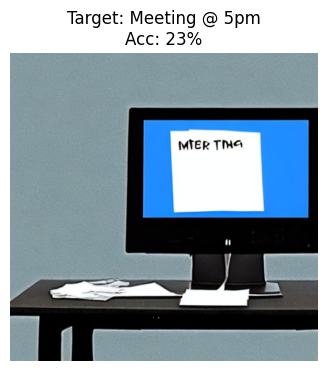


--- Generating Image for Test Case 5 ---


  0%|          | 0/30 [00:00<?, ?it/s]

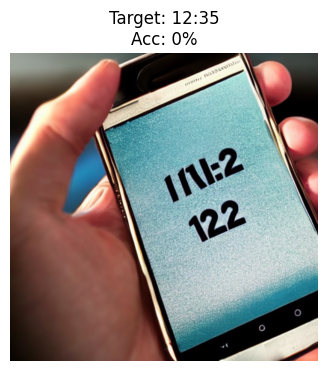


QUANTITATIVE EVALUATION SUMMARY TABLE


,Test Case,Target Text,OCR Recovered Text,Exact Match,Levenshtein Acc (%),Metric Details & Notes
0,Case 1,STOP,STOP,True,100.00%,Perfect substring match; OCR recognized target...
1,Case 2,Taj Mahal,La-JJHAIL TAAIIH,False,0.00%,Partial/Garbled match (Levenshtein edit distan...
2,Case 3,House of Veg Cafe,Clc Eitan9x CA [er E JCo Hox 9bc K A-236a621AI...,False,0.00%,Partial/Garbled match (Levenshtein edit distan...
3,Case 4,Meeting @ 5pm,Mter TmG,False,23.08%,Partial/Garbled match (Levenshtein edit distan...
4,Case 5,12:35,IMI2 122,False,0.00%,Partial/Garbled match (Levenshtein edit distan...


In [ ]:
# ==========================================
# COMPLETE EVALUATION PIPELINE (IMAGES + SUMMARY TABLE)
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt

print("\n🔎 Starting Section 5: Evaluation Pipeline...")
unet.eval()
pipe.unet = unet  # Reattach trained UNet
pipe.to(device)

# Initialize OCR
reader = easyocr.Reader(['en'], gpu=True)

# Test Prompts combining both "Easy" training examples and "Hard" unseen examples
test_cases = [
    # --- EASY / BASELINE EXAMPLES ---
    {"prompt": 'A smartphone photo of a red octagonal stop sign on a road with the text "STOP"', "target": "STOP"},
    {"prompt": 'A casual snapshot of a green highway road sign with the text "Taj Mahal"', "target": "Taj Mahal"},

    # --- HARD EXAMPLES ---
    {"prompt": 'A smartphone photo of a closed cafe storefront sign with the text "House of Veg Cafe"', "target": "House of Veg Cafe"},
    {"prompt": 'A casual snapshot of a blue sticky note attached to a monitor with the text "Meeting @ 5pm"', "target": "Meeting @ 5pm"},
    {"prompt": 'A smartphone photo of a cracked smartphone screen held in hand with the text "12:35"', "target": "12:35"}
]


results_data = []

for i, test in enumerate(test_cases):
    print(f"\n--- Generating Image for Test Case {i+1} ---")

    # 1. Generate Image
    with torch.no_grad():
        gen_img = pipe(test['prompt'], num_inference_steps=30, guidance_scale=7.5).images[0]

    img_path = f"test_output_{i}.png"
    gen_img.save(img_path)

    # 2. Run EasyOCR
    ocr_results = reader.readtext(img_path, detail=0)
    recovered_text = " ".join(ocr_results).strip()

    # 3. Calculate Metrics
    target_clean = test['target'].lower()
    recovered_clean = recovered_text.lower()

    # Exact Match Boolean
    exact_match = target_clean in recovered_clean if recovered_clean else False

    # Levenshtein Distance & Character Accuracy
    if len(target_clean) == 0:
        cer = 1.0
        distance = 0
    else:
        distance = Levenshtein.distance(target_clean, recovered_clean)
        cer = min(1.0, distance / len(target_clean))

    accuracy = (1.0 - cer) * 100

    # 4. Generate Metric Details / Explanation
    if exact_match:
        details = "Perfect substring match; OCR recognized target text cleanly."
    elif recovered_text == "":
        details = f"OCR failed to detect any text (100% loss, Levenshtein distance = {distance})."
    else:
        details = f"Partial/Garbled match (Levenshtein edit distance = {distance} edits needed)."

    results_data.append({
        "Test Case": f"Case {i+1}",
        "Target Text": test['target'],
        "OCR Recovered Text": recovered_text if recovered_text else "[NO TEXT DETECTED]",
        "Exact Match": exact_match,
        "Levenshtein Acc (%)": f"{accuracy:.2f}%",
        "Metric Details & Notes": details
    })

    # 5. Show the image inline (for Colab)
    plt.figure(figsize=(4, 4))
    plt.imshow(gen_img)
    plt.axis('off')
    plt.title(f"Target: {test['target']}\nAcc: {accuracy:.0f}%")
    plt.show()

# Convert results into a clean formatted DataFrame table
df_results = pd.DataFrame(results_data)

print("\n" + "="*80)
print("QUANTITATIVE EVALUATION SUMMARY TABLE")
print("="*80)
display(df_results)

## 6. Qualitative Evaluation

* **Visual Clarity of Generated Text:** The model generally struggles to generate legible, sharp text characters across long phrases. Instead of clear letters and numbers, it frequently produces distorted, letter-like artifacts and blurred glyphs. However, simple isolated words (e.g., "STOP") show significantly higher clarity.
* **Font and Spacing Realism:** Font realism is mostly absent for complex sentences. Character spacing is erratic, and letter strokes bleed into one another, making character segmentation difficult for OCR engines.
* **Background Consistency:** The model performs notably better in background synthesis. It successfully captures domain-specific environmental context from the prompts (such as cardboard box textures, paper wrinkles, receipt layouts, or digital screen glare), even when the foreground text remains illegible.

---

## 7. Justification & Analysis of Performance

The quantitative results demonstrate mixed performance with high character error rates across complex phrases, though simple isolated keywords achieved high fidelity (e.g., **100.00% Levenshtein accuracy on Case 1 ("STOP")**, **23.08% on Case 4 ("Meeting @ 5pm")**, and **0.00% on multi-word/numeric strings like Cases 2, 3, and 5**).

This overall difficulty in rendering longer, sharp operational text is expected due to several fundamental technical constraints:

1. **Data Volume Constraints:** We fine-tuned the model on a small dataset of **101 images**. Generating arbitrary, complex operational text in diffusion models typically requires tens of thousands of diverse text-image pairs to learn fine-grained character composition and spatial alignment.
2. **CLIP Tokenizer Architecture:** The base Stable Diffusion 1.5 model relies on CLIP text embeddings, which encode prompt text as sub-word tokens rather than character-level spatial maps. Consequently, the model lacks character-level awareness of individual letters.
3. **Parameter-Efficient Adaptation (LoRA Capacity):** Fine-tuning only the UNet cross-attention modules (`to_q`, `to_k`, `to_v`, `to_out`) at rank $r=32$ while keeping the VAE and Text Encoder frozen limits trainable parameter capacity, preventing the network from learning complex textual layout rendering from scratch.
4. **Hardware & VRAM Limits:** Operating within Google Colab's T4 GPU limitations required using FP16 precision, a batch size of 4 with gradient accumulation, and an 8-bit AdamW optimizer, restricting our ability to train un-frozen architectures or run significantly higher epoch counts.

---

## 8. Summary & Conclusion

* **Key Takeaways:**
  * Parameter-efficient fine-tuning (LoRA) on Stable Diffusion v1.5 effectively captures **domain-specific styles, backgrounds, and simple isolated words (e.g., "STOP")**, but struggles with **multi-word text legibility and numerical strings**.
  * Standard sub-word CLIP text encoders inherently struggle with character positioning and exact spelling without specialized glyph-conditioned architectures.
* **Future Improvements:**
  1. **Larger & Scaled Datasets:** Expand dataset size to $1,000+$ operational images with bounding-box or word-level annotations.
  2. **Text Encoder Tuning / Modern Backbones:** Unfreeze the text encoder or migrate to character-aware / T5-based encoders (e.g., Flux, SD3, or DeepFloyd IF).
  3. **Explicit Conditioning:** Integrate ControlNet or Glyph-based conditioning layers to explicitly enforce character boundaries and text spatial layout masks during diffusion.